## Verteilung der relativen Häufigkeit $H=X/n$

Für $X\sim B(n,p)$ ist $H=X/n$ die relative Häufigkeit der Treffer. Das Stabdiagramm zeigt ihre Wahrscheinlichkeitsverteilung. Dabei gilt

$$
P(H=h)=P(X=k)\qquad\text{für}\qquad h=\frac{k}{n}.
$$

Die möglichen Werte von $H$ liegen damit auf dem diskreten Gitter $0,1/n,2/n,\ldots,1$. Ein ausgewählter Wert kann in der Grafik hervorgehoben werden.

## Eingaben

Nur die folgende Zelle muss verändert werden. Die Klasse `Config` bündelt vier Arten von Eingaben:

- mathematische Eingaben,
- Ausschnitt und Elemente der Grafik,
- Beschriftung,
- Anzeige und Speicherung.

Der hervorgehobene Wert wird bewusst durch die ganzzahlige Trefferzahl $k$ eingegeben. Die relative Häufigkeit $h=k/n$ wird daraus berechnet. So kann nur ein Wert markiert werden, der für den gewählten Stichprobenumfang tatsächlich möglich ist. Für die Standardeinstellungen gilt $k=68$ und damit $h=68/400=0{,}17$.

In [9]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.ticker import FuncFormatter
import numpy as np
from scipy.stats import binom


plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})


@dataclass(frozen=True)
class Config:
    # Mathematische Eingaben
    n: int = 380
    p: float = 0.15
    k: int = 60

    # Ausschnitt und Elemente der Grafik
    x_min: float = 0.09
    x_max: float = 0.21
    #x_min: float = 0.0875
    #x_max: float = 0.1925
    y_max: float = 0.063
    x_tick_step: float = 0.01
    y_ticks: tuple[float, ...] = (0.00, 0.02, 0.04, 0.06)
    show_marked_value: bool = False

    # Beschriftung der Grafik
    show_title: bool = True
    show_subtitle: bool = True

    # Ausgabe des Notebooks
    show_figure: bool = True
    save_figure: bool = True
    save_formats: tuple[str, ...] = ("png", "pdf")
    output_dir: str = "fig"
    png_dpi: int = 240


cfg = Config()

## Prüfung und mathematische Berechnung

Zunächst werden die Eingaben geprüft. Danach berechnet `calculate()` die möglichen Werte $h=k/n$ und ihre Wahrscheinlichkeiten. Die mathematische Berechnung greift nicht auf globale Zwischenwerte zu.

Die ganzzahlige Eingabe von $k$ macht eine nachträgliche Prüfung, ob der markierte Wert auf dem Gitter von $H$ liegt, überflüssig: Seine Realisierbarkeit ist bereits durch die Eingabe gesichert.

In [10]:
@dataclass(frozen=True)
class Calculation:
    k_values: np.ndarray
    h_values: np.ndarray
    probabilities: np.ndarray
    marked: np.ndarray
    marked_h: float


def validate_config(cfg: Config) -> None:
    if not isinstance(cfg.n, int) or isinstance(cfg.n, bool) or cfg.n <= 0:
        raise ValueError("n muss eine positive ganze Zahl sein.")
    if not 0.0 <= cfg.p <= 1.0:
        raise ValueError("p muss zwischen 0 und 1 liegen.")
    if not isinstance(cfg.k, int) or isinstance(cfg.k, bool):
        raise ValueError("k muss eine ganze Zahl sein.")
    if not 0 <= cfg.k <= cfg.n:
        raise ValueError("k muss zwischen 0 und n liegen.")
    if not 0.0 <= cfg.x_min < cfg.x_max <= 1.0:
        raise ValueError("Es muss 0 <= x_min < x_max <= 1 gelten.")
    if cfg.y_max <= 0.0:
        raise ValueError("y_max muss positiv sein.")
    if cfg.x_tick_step <= 0.0:
        raise ValueError("x_tick_step muss positiv sein.")
    if any(tick < 0.0 or tick > cfg.y_max for tick in cfg.y_ticks):
        raise ValueError("Alle y_ticks müssen zwischen 0 und y_max liegen.")

    marked_h = cfg.k / cfg.n
    if not cfg.x_min <= marked_h <= cfg.x_max:
        raise ValueError("Der markierte Wert k/n liegt außerhalb des sichtbaren Ausschnitts.")

    if cfg.png_dpi <= 0:
        raise ValueError("png_dpi muss positiv sein.")
    if not cfg.output_dir.strip():
        raise ValueError("output_dir darf nicht leer sein.")
    if Path(cfg.output_dir).is_absolute():
        raise ValueError("output_dir muss ein relativer Pfad sein.")

    formats = {fmt.lower().lstrip(".") for fmt in cfg.save_formats}
    if cfg.save_figure and not formats:
        raise ValueError("save_formats darf beim Speichern nicht leer sein.")
    unsupported = formats - {"png", "pdf"}
    if unsupported:
        names = ", ".join(sorted(unsupported))
        raise ValueError(f"Nicht unterstützte Speicherformate: {names}")


def calculate(cfg: Config) -> Calculation:
    validate_config(cfg)

    all_k = np.arange(cfg.n + 1)
    all_h = all_k / cfg.n
    all_probabilities = binom.pmf(all_k, cfg.n, cfg.p)
    visible = (cfg.x_min <= all_h) & (all_h <= cfg.x_max)

    k_values = all_k[visible]
    h_values = all_h[visible]
    probabilities = all_probabilities[visible]
    marked = k_values == cfg.k

    if not np.any(marked):
        raise AssertionError("Der markierte Wert fehlt im sichtbaren Ausschnitt.")

    return Calculation(
        k_values=k_values,
        h_values=h_values,
        probabilities=probabilities,
        marked=marked,
        marked_h=cfg.k / cfg.n,
    )

## Grafik

Die Funktion `create_figure()` erzeugt ausschließlich die Grafik. Der markierte Stab sowie Titel und Untertitel können unabhängig voneinander ein- und ausgeblendet werden.

Der Untertitel enthält nur die Eingaben $n$, $p$ und -- falls die Markierung sichtbar ist -- $k$. Eine Ergebniszeile gibt es nicht: Die diskrete Struktur und die Lage des hervorgehobenen Wertes sollen aus der Grafik selbst gelesen werden.

In [11]:
def format_decimal(value: float, _position: int) -> str:
    if np.isclose(value, 0.0):
        return "0"
    return f"{value:.2f}".replace(".", ",")


def x_tick_values(cfg: Config) -> np.ndarray:
    first = np.ceil((cfg.x_min - 1e-12) / cfg.x_tick_step) * cfg.x_tick_step
    last = np.floor((cfg.x_max + 1e-12) / cfg.x_tick_step) * cfg.x_tick_step
    return np.arange(first, last + 0.5 * cfg.x_tick_step, cfg.x_tick_step)


def create_figure(
    cfg: Config,
    calculation: Calculation,
) -> tuple[Figure, Axes]:
    fig, ax = plt.subplots(figsize=(10.2, 3.6))

    if cfg.show_marked_value:
        ordinary = ~calculation.marked
    else:
        ordinary = np.ones_like(calculation.marked, dtype=bool)

    ax.vlines(
        calculation.h_values[ordinary],
        0.0,
        calculation.probabilities[ordinary],
        color="tab:blue", 
        linewidth=2.1,
        zorder=2,
    )
    ax.scatter(
        calculation.h_values[ordinary],
        calculation.probabilities[ordinary],
        color="tab:blue",
        s=19,
        zorder=3,
    )

    if cfg.show_marked_value:
        ax.vlines(
            calculation.h_values[calculation.marked],
            0.0,
            calculation.probabilities[calculation.marked],
            color="tab:red",
            linewidth=3.0,
            zorder=4,
        )
        ax.scatter(
            calculation.h_values[calculation.marked],
            calculation.probabilities[calculation.marked],
            color="tab:red",
            s=31,
            zorder=5,
        )

    ax.set_xlim(cfg.x_min, cfg.x_max)
    ax.set_ylim(0.0, cfg.y_max)
    ax.set_xticks(x_tick_values(cfg))
    ax.set_yticks(cfg.y_ticks)
    ax.xaxis.set_major_formatter(FuncFormatter(format_decimal))
    ax.yaxis.set_major_formatter(FuncFormatter(format_decimal))

    ax.set_xlabel(rf"$h=k/{cfg.n}$", fontsize=16, labelpad=7)
    
    ax.set_ylabel(
    r"$P(H=h)$",
    fontsize=16,
    labelpad=8,
    )

    ax.tick_params(axis="both", labelsize=12, length=4, width=0.8)
    for spine in ax.spines.values():
        spine.set_color("0.25")
        spine.set_linewidth(0.8)

    title = r"Verteilung der relativen Häufigkeit $H=X/n$"
    if cfg.show_marked_value:
        subtitle = rf"$n={cfg.n},\quad p={cfg.p:.2f},\quad k={cfg.k}$"
    else:
        subtitle = rf"$n={cfg.n},\quad p={cfg.p:.2f}$"

    if cfg.show_title and cfg.show_subtitle:
        ax.set_title(title, fontsize=16, pad=32)
        ax.text(
            0.5,
            1.03,
            subtitle,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=12,
            color="0.35",
        )
    elif cfg.show_title:
        ax.set_title(title, fontsize=16, pad=13)
    elif cfg.show_subtitle:
        ax.set_title(subtitle, fontsize=11, color="0.35", pad=13)

    fig.tight_layout()
    return fig, ax

## Ausgabe

Berechnung, Erzeugung der Grafik sowie Anzeige und Speicherung bleiben getrennt. Die Grafik kann unabhängig voneinander angezeigt und gespeichert werden.

Ist `save_figure = True`, wird der relative Unterordner `fig/` bei Bedarf automatisch angelegt. PNG- und PDF-Dateien werden dort gesammelt; das Verzeichnis des Notebooks bleibt frei von einzelnen Grafikdateien.

Der Dateiname wird automatisch aus den mathematischen Eingaben gebildet. Für die Standardeinstellungen entstehen

- `Binomialverteilung-H-n400-p014-k68.png`,
- `Binomialverteilung-H-n400-p014-k68.pdf`.

Die letzte Zelle zeigt ausschließlich die Grafik. Eine zusätzliche Ergebniszeile wird bewusst nicht ausgegeben.

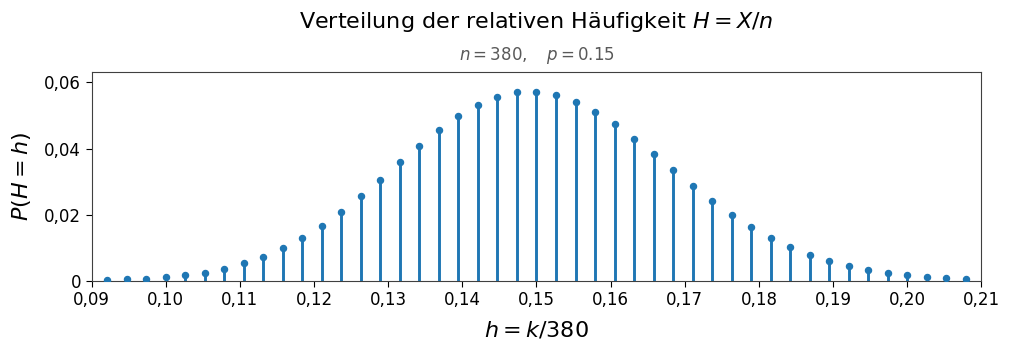

In [12]:
def probability_token(value: float) -> str:
    text = f"{value:.6f}".rstrip("0").rstrip(".")
    integer, separator, decimals = text.partition(".")
    decimals = decimals.ljust(2, "0") if separator else "00"
    return f"{integer}{decimals}".replace("-", "m")


def figure_stem(cfg: Config) -> str:
    p = probability_token(cfg.p)
    return f"Binomialverteilung-H-n{cfg.n}-p{p}-k{cfg.k}"


def save_figure(
    fig: Figure,
    cfg: Config,
) -> tuple[Path, ...]:
    output_dir = Path(cfg.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    stem = figure_stem(cfg)
    saved_files: list[Path] = []

    for raw_format in cfg.save_formats:
        file_format = raw_format.lower().lstrip(".")
        output_path = output_dir / f"{stem}.{file_format}"
        save_options: dict[str, object] = {"bbox_inches": "tight"}
        if file_format == "png":
            save_options["dpi"] = cfg.png_dpi
        fig.savefig(output_path, **save_options)
        saved_files.append(output_path)

    return tuple(saved_files)


def run(cfg: Config) -> tuple[Calculation, tuple[Path, ...]]:
    calculation = calculate(cfg)
    fig, _ = create_figure(cfg, calculation)

    saved_files: tuple[Path, ...] = ()
    if cfg.save_figure:
        saved_files = save_figure(fig, cfg)

    if cfg.show_figure:
        plt.show()
    else:
        plt.close(fig)

    return calculation, saved_files


calculation, saved_files = run(cfg)